## EDA

In [133]:
# --------------------------------
# IMPORTS
# --------------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option(
    'display.float_format',
    '{:.2f}'.format
)


In [134]:
# --------------------------------
# PRESENTATION STYLE
# --------------------------------

sns.set_theme(
    style='whitegrid',
    context='talk'
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

In [135]:
df = pd.read_csv('../01_data/01_raw_data/hour.csv')

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.29,0.81,0.00,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.27,0.80,0.00,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.27,0.80,0.00,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.29,0.75,0.00,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.29,0.75,0.00,0,1,1


In [136]:
# Feature Types and Target Definition

binary_features=['yr', 'holiday', 'weekday', 'workingday', 'weathersit']
numeric_features=['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']
categorical_features=['season', 'mnth', 'hr', 'weekday', 'weathersit']

target=['cnt']


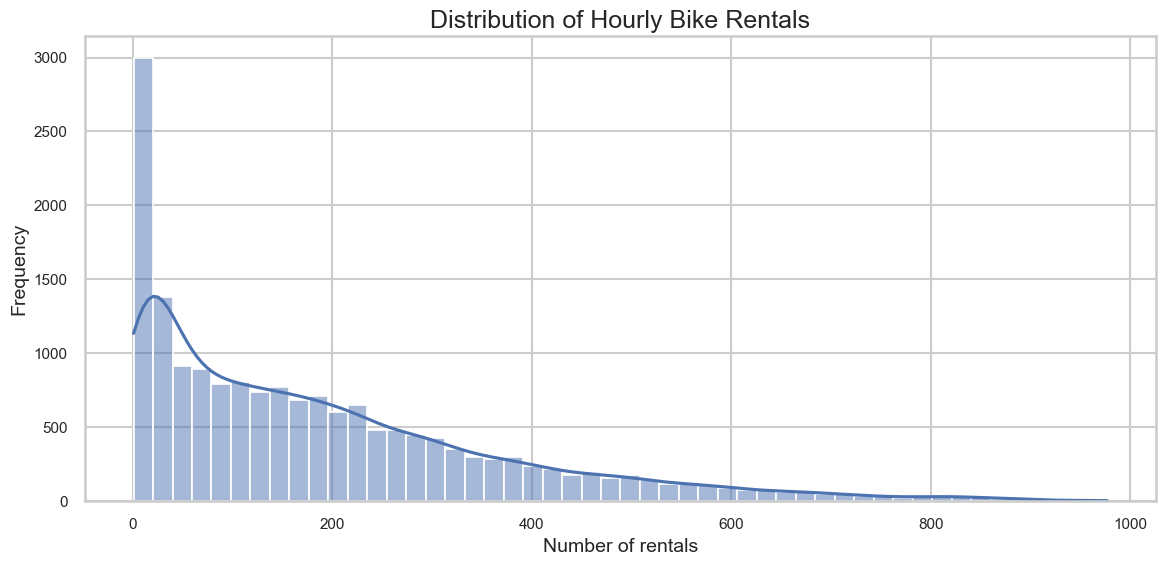

In [137]:
# --------------------------------
# TARGET DISTRIBUTION
# --------------------------------

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='cnt',
    bins=50,
    kde=True
)

plt.title('Distribution of Hourly Bike Rentals')
plt.xlabel('Number of rentals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [138]:
print(f"Mean:   {df['cnt'].mean():.1f}")
print(f"Median: {df['cnt'].median():.1f}")
print(f"Max:    {df['cnt'].max():.0f}")

Mean:   189.5
Median: 142.0
Max:    977


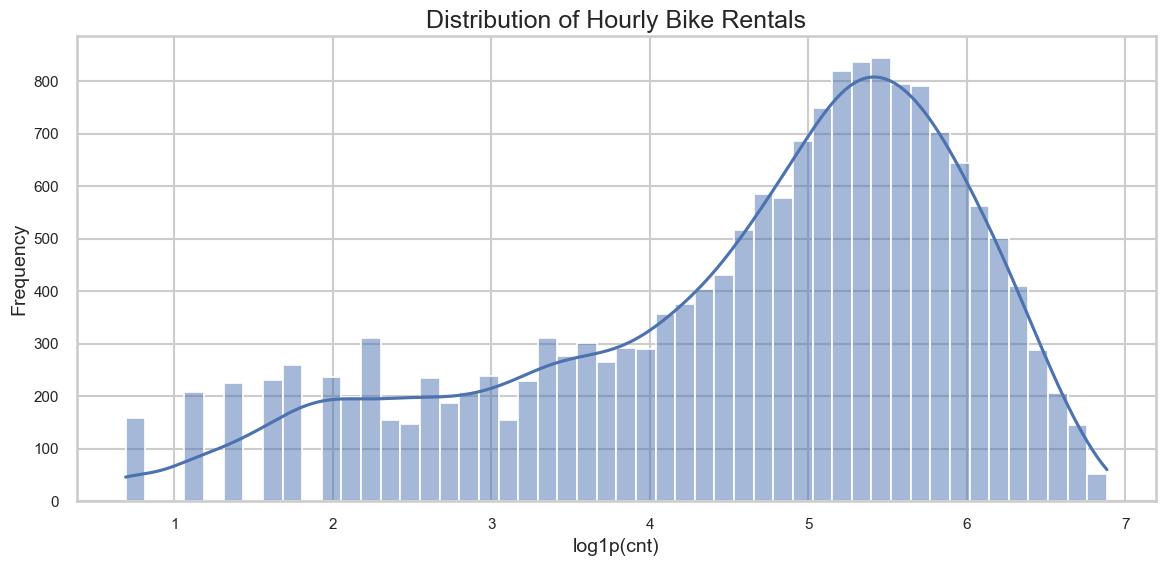

In [139]:
df['log_cnt'] = np.log1p(df['cnt'])

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="log_cnt",
    bins=50,
    kde=True
)
plt.title('Distribution of Hourly Bike Rentals')
plt.xlabel('log1p(cnt)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

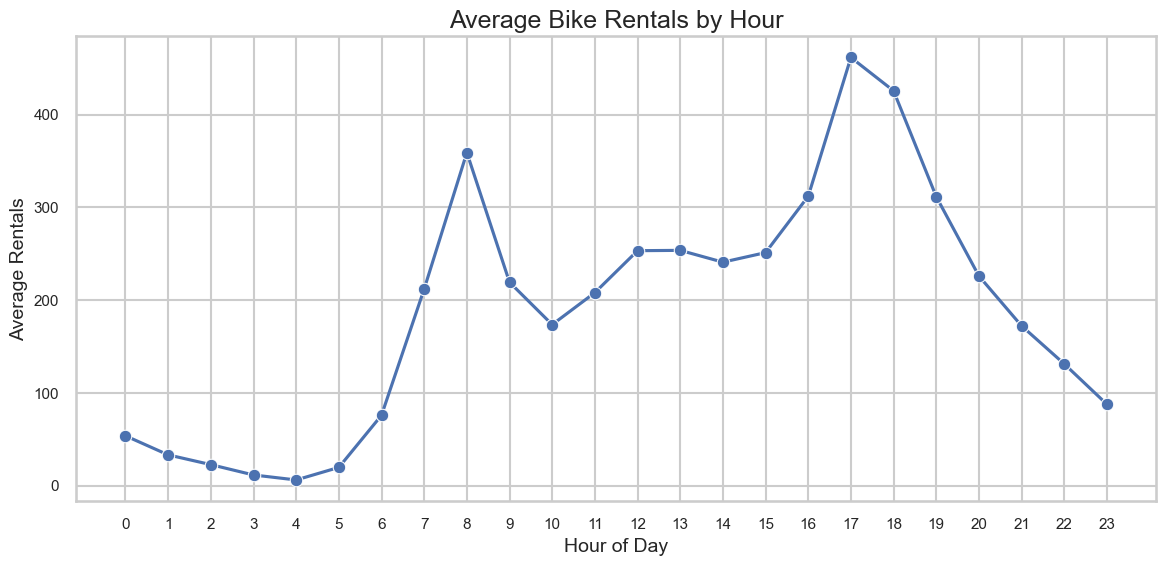

In [140]:
# --------------------------------
# AVERAGE RENTALS BY HOUR
# --------------------------------

hourly_avg = (
    df.groupby('hr')['cnt']
    .mean()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_avg.index,
    y=hourly_avg.values,
    marker="o"
)

plt.title('Average Bike Rentals by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')

plt.xticks(range(24))

plt.tight_layout()
plt.show()

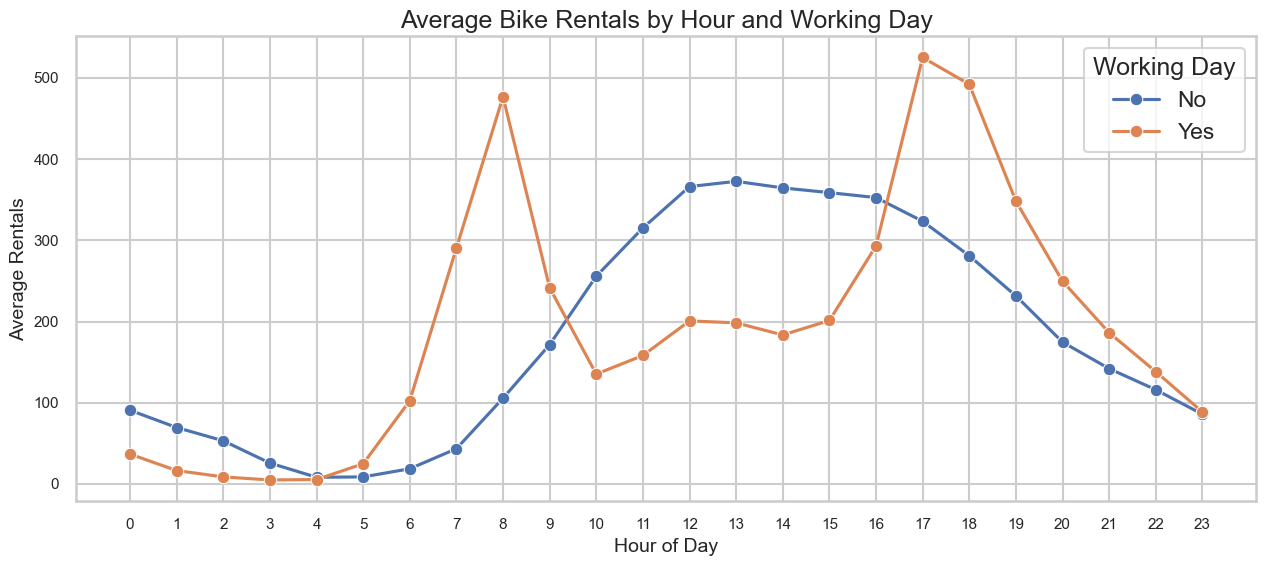

In [141]:
# --------------------------------
# WORKING DAY × HOUR
# --------------------------------

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=df,
    x='hr',
    y='cnt',
    hue='workingday',
    estimator='mean',
    errorbar=None,
    marker="o"
)

plt.title('Average Bike Rentals by Hour and Working Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rentals')

plt.xticks(range(24))

plt.legend(
    title='Working Day',
    labels=['No', 'Yes']
)

plt.tight_layout()
plt.show()

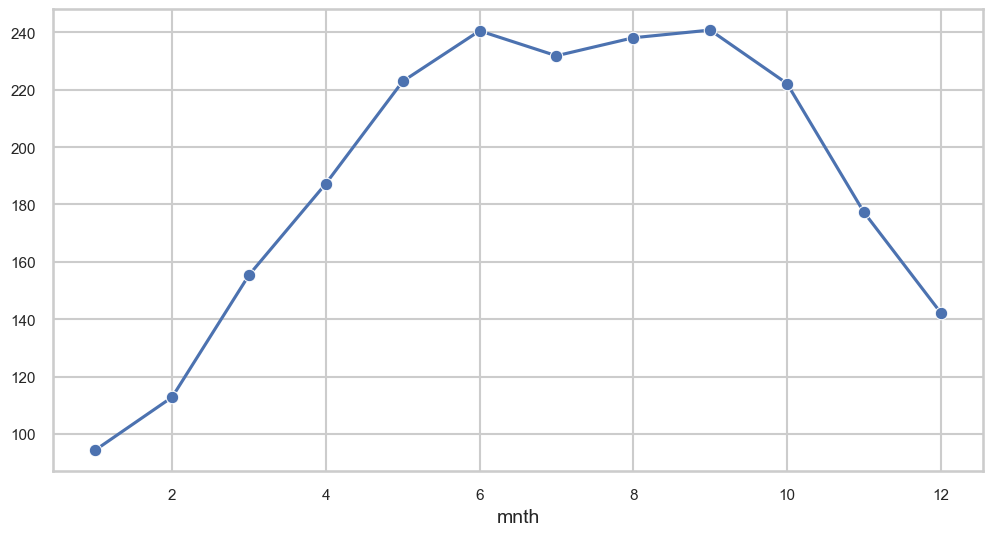

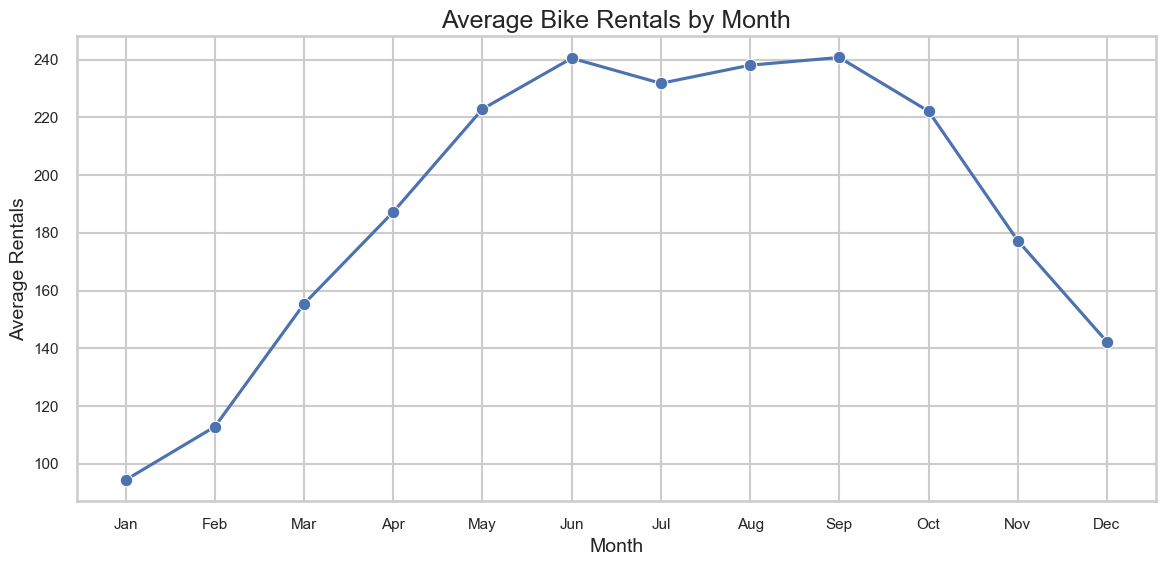

In [142]:
# --------------------------------
# AVERAGE RENTALS BY MONTH
# --------------------------------

monthly_avg = (
    df.groupby('mnth')['cnt']
    .mean()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_avg.index,
    y=monthly_avg.values,
    marker='o'
)

month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_avg.index,
    y=monthly_avg.values,
    marker="o"
)

plt.title('Average Bike Rentals by Month')
plt.xlabel('Month')
plt.ylabel('Average Rentals')

plt.xticks(
    range(1, 13),
    month_labels
)

plt.tight_layout()
plt.show()

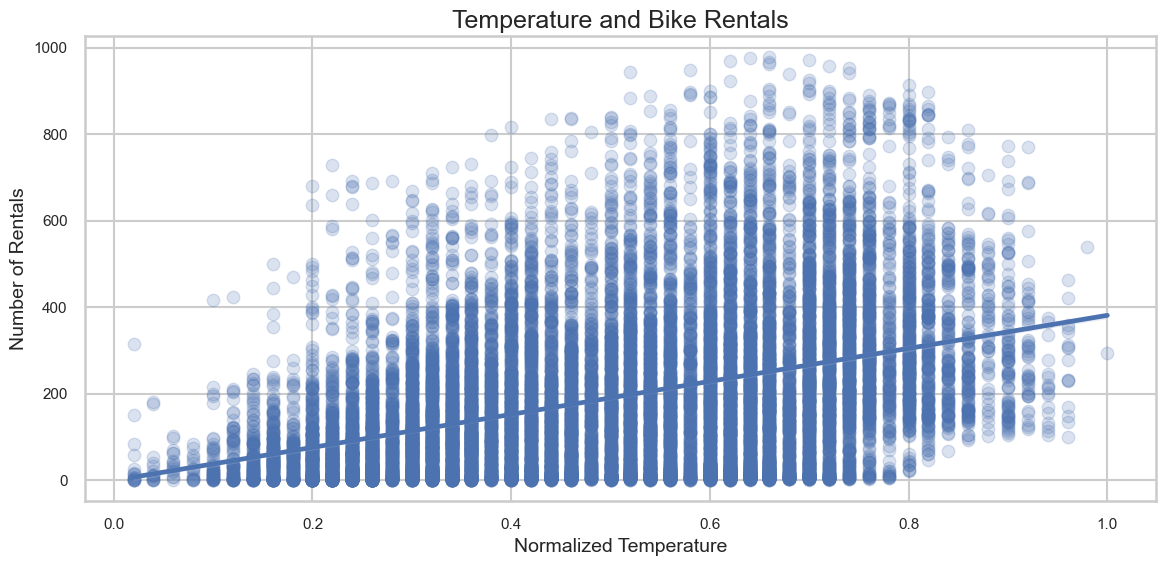

In [143]:
# --------------------------------
# TEMPERATURE VS RENTALS
# --------------------------------

plt.figure(figsize=(12, 6))

sns.regplot(
    data=df,
    x='temp',
    y='cnt',
    scatter_kws={'alpha': 0.2},
    line_kws={}
)

plt.title('Temperature and Bike Rentals')
plt.xlabel('Normalized Temperature')
plt.ylabel('Number of Rentals')

plt.tight_layout()
plt.show()

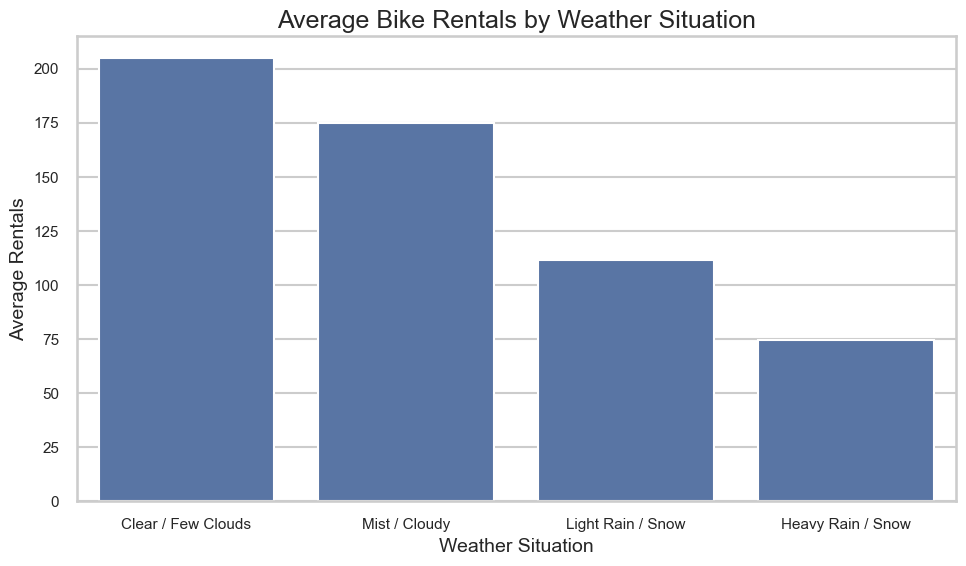

In [144]:
# --------------------------------
# WEATHER SITUATION
# --------------------------------

weather_avg = (
    df.groupby('weathersit')['cnt']
    .mean()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=weather_avg.index,
    y=weather_avg.values
)

plt.title('Average Bike Rentals by Weather Situation')
plt.xlabel('Weather Situation')
plt.ylabel('Average Rentals')


weather_labels = {
    1: 'Clear / Few Clouds',
    2: 'Mist / Cloudy',
    3: 'Light Rain / Snow',
    4: 'Heavy Rain / Snow'
}

plt.xticks(
        ticks=range(len(weather_avg)),
        labels=[weather_labels[i] for i in weather_avg.index]
)

plt.tight_layout()
plt.show()

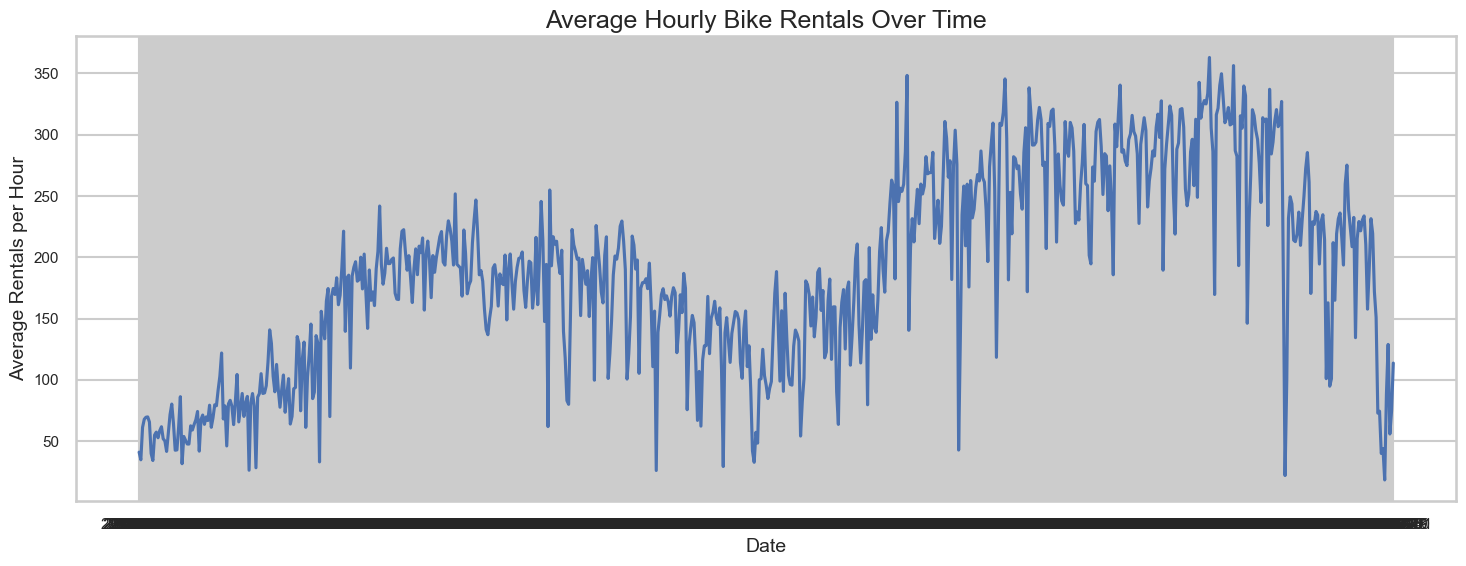

In [145]:
# --------------------------------
# DAILY AVERAGE RENTALS
# --------------------------------

daily_avg = (
    df.groupby('dteday')['cnt']
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    daily_avg.index,
    daily_avg.values
)

plt.title('Average Hourly Bike Rentals Over Time')
plt.xlabel('Date')
plt.ylabel('Average Rentals per Hour')

plt.tight_layout()
plt.show()

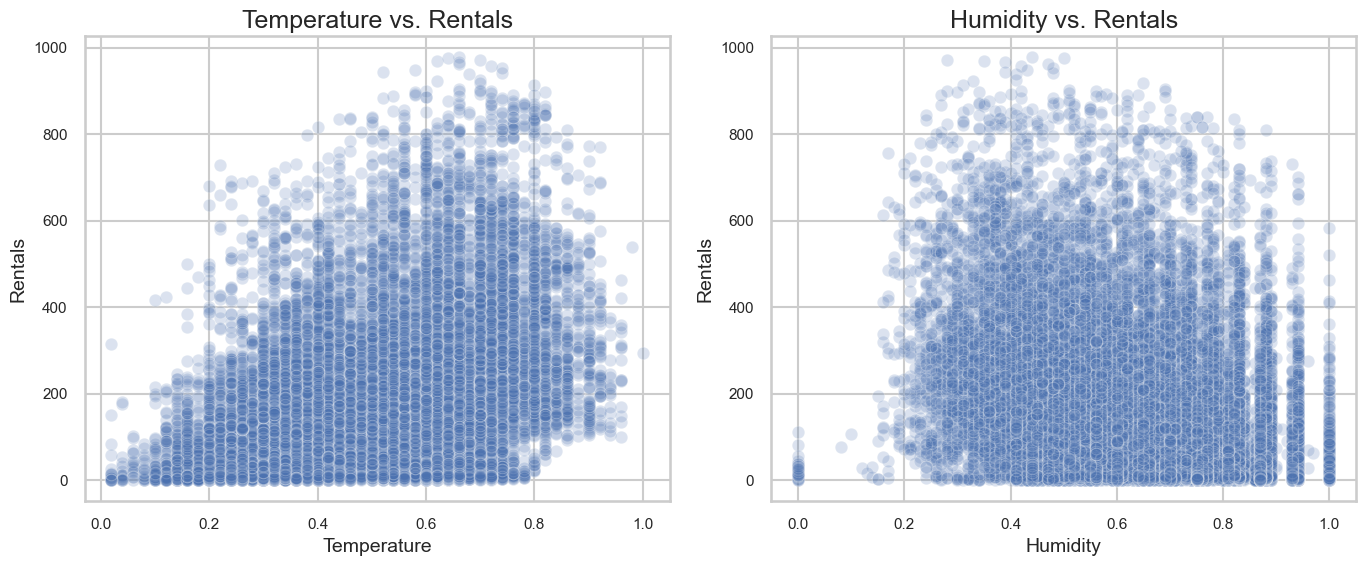

In [146]:
# --------------------------------
# WEATHER FEATURES VS RENTALS
# --------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

sns.scatterplot(
    data=df,
    x="temp",
    y="cnt",
    alpha=0.2,
    ax=axes[0]
)

axes[0].set_title('Temperature vs. Rentals')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Rentals')


sns.scatterplot(
    data=df,
    x='hum',
    y='cnt',
    alpha=0.2,
    ax=axes[1]
)

axes[1].set_title('Humidity vs. Rentals')
axes[1].set_xlabel('Humidity')
axes[1].set_ylabel('Rentals')

plt.tight_layout()
plt.show()

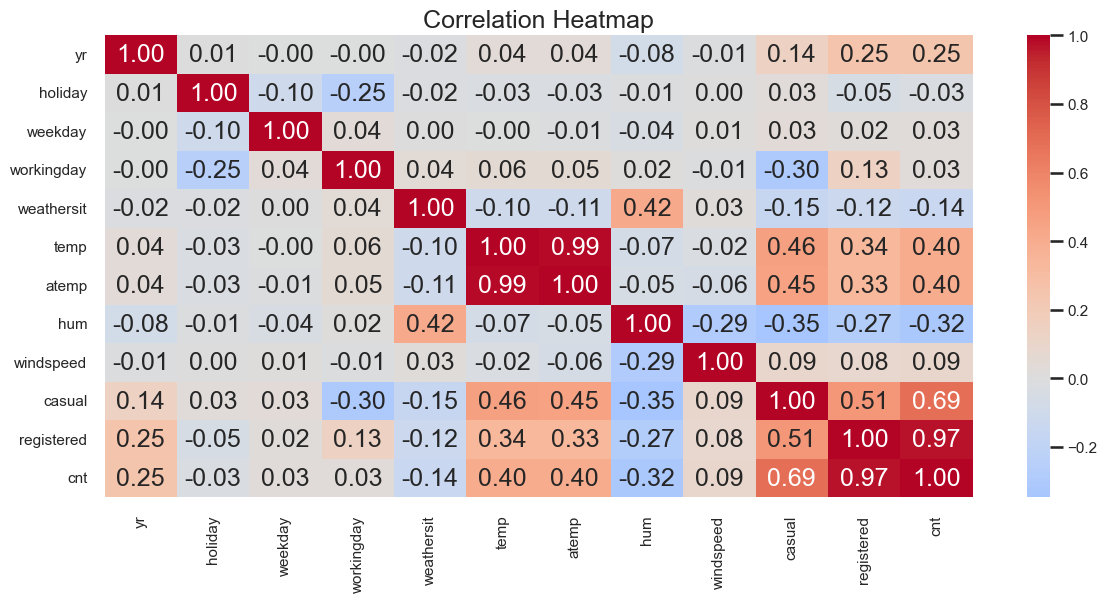

In [147]:
# Correlation Heatmap

features_target_for_corr = (binary_features + numeric_features + target)

corr = df[features_target_for_corr].corr()

plt.figure(figsize=(14, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [148]:
df[['temp', 'hum', 'windspeed', 'cnt']].corr(method='spearman')

,temp,hum,windspeed,cnt
temp,1.00,-0.06,-0.01,0.42
hum,-0.06,1.00,-0.29,-0.36
windspeed,-0.01,-0.29,1.00,0.13
cnt,0.42,-0.36,0.13,1.00


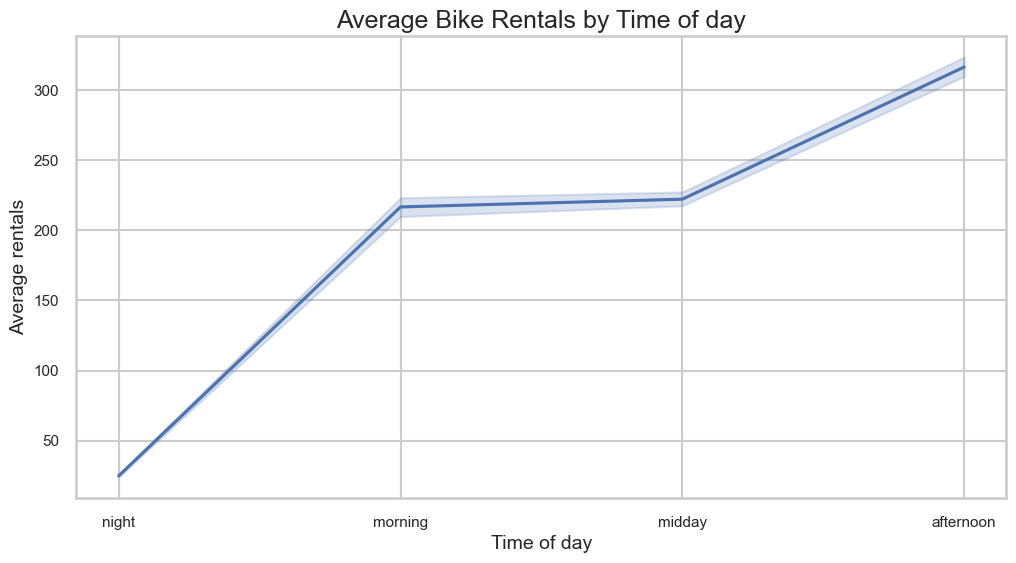

In [149]:
# --------------------------------
# FEATURE ENGINEERING
# --------------------------------

# Difference temp actual vs. temp felt

df['temp_diff'] = df['temp'] - df['atemp']


# Time of day with 4 categories

def get_time_of_day(hour):
    if 0 <= hour < 6:
        return "night"
    elif 6 <= hour < 10:
        return "morning"
    elif 10 <= hour < 14:
        return "midday"
    elif 14 <= hour < 18:
        return "afternoon"
    else:
        return

df['time_of_day'] = df['hr'].apply(get_time_of_day)


sns.lineplot(
    data=df,
    x='time_of_day',
    y='cnt',
    estimator='mean'
)

plt.title('Average Bike Rentals by Time of day')
plt.xlabel('Time of day')
plt.ylabel('Average rentals')
plt.show()

# df['users_diff'] = df['registered'] - df['casual']   # too high correlation with target

#numeric_features=['temp', 'atemp', 'temp_diff', 'hum', 'windspeed', 'casual', 'registered', 'users_reg_per']

#features_target_for_corr = (binary_features + numeric_features + target)

#corr = df[features_target_for_corr].corr()

#plt.figure(figsize=(10, 6))
#sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
#plt.title("Correlation Heatmap")
#plt.show()

# preference for temp and temp_diff (good interpretability, good correlation)

In [150]:
df.to_csv("../01_data/02_processed_data/hour.csv", index=False)
